SGS 算法实现（基于皮尔逊相关系数的条件独立检验）
- 通过条件独立检验（皮尔逊相关系数衍生的条件相关系数）构建无向图骨架，判断变量间是否存在直接因果关联（SGS 算法核心：移除条件独立的变量对边）

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

def is_independent(X, Y, Z):
    """
    条件独立检验函数：使用皮尔逊相关系数推导条件相关系数，判断X和Y在给定Z（可多维）时是否独立
    参数：
        X: 一维数组，变量X的观测值
        Y: 一维数组，变量Y的观测值
        Z: 一维/多维数组，条件变量Z的观测值（多维时需展平为一维）
    返回：
        bool: True表示条件独立，False表示条件依赖
    原理：
        条件相关系数公式：r_xy|z = (r_xy - r_xz*r_yz) / sqrt((1-r_xz²)(1-r_yz²))
        当Z为多维时，简化为计算X与Z的平均相关、Y与Z的平均相关（非严格推导，仅为演示）
    """
    # 1. 计算X与Y的边际相关系数
    r_xy = pearsonr(X, Y)[0]  # pearsonr返回(相关系数, p值)，取第一个元素

    # 2. 处理条件变量Z：若多维则展平，计算X与Z、Y与Z的平均相关系数
    Z_flat = Z.flatten()  # 展平Z（避免多维数组导致的计算错误）
    r_xz = pearsonr(X, Z_flat)[0]  # X与Z的相关系数
    r_yz = pearsonr(Y, Z_flat)[0]  # Y与Z的相关系数

    # 3. 计算条件相关系数（仅适用于Z为单变量或多维但可简化为平均相关的场景）
    denominator = np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
    r_xy_z = (r_xy - r_xz * r_yz) / denominator if denominator != 0 else 0

    # 4. 基于阈值判断独立性（|r_xy_z| < 0.5 视为独立，阈值可调整）
    return abs(r_xy_z) < 0.5

def sgs_algorithm(data, alpha=0.05):
    """
    简化版SGS（Spirtes-Glymour-Scheines）算法：从完全图出发，通过条件独立检验删除边
    参数：
        data: pd.DataFrame，每行是一个样本，每列是一个变量
        alpha: 显著性水平（此处未使用，因is_independent用了阈值法）
    返回：
        pd.DataFrame: 邻接矩阵（1表示有边，0表示无边）
    算法步骤：
        1. 初始化完全图（所有变量间都有边）
        2. 对每对变量(X,Y)，以所有其他变量为条件，检验X与Y是否条件独立
        3. 若独立，则删除X与Y之间的边；否则保留
    注意：
        简化版未考虑条件集的子集递增（真实SGS需按条件集大小从0开始逐步增加），仅适用于演示
    """
    num_vars = data.shape[1]  # 变量个数
    # 初始化邻接矩阵：完全图（对角线也为1，后续无影响）
    adjacency_matrix = pd.DataFrame(
        np.ones((num_vars, num_vars)),
        columns=data.columns,
        index=data.columns
    )

    # 遍历所有变量对（i<j，避免重复计算）
    for i in range(num_vars):
        for j in range(i+1, num_vars):
            # 条件集：除X(i)和Y(j)外的所有变量
            conditions = data.drop([data.columns[i], data.columns[j]], axis=1)
            # 检验X与Y在条件集下是否独立
            if is_independent(
                data[data.columns[i]],  # 变量X
                data[data.columns[j]],  # 变量Y
                conditions.values       # 条件变量Z（多维数组）
            ):
                # 若独立，删除双向边
                adjacency_matrix.at[data.columns[i], data.columns[j]] = 0
                adjacency_matrix.at[data.columns[j], data.columns[i]] = 0

    return adjacency_matrix

# 生成示例数据：3个变量的多元正态分布（X与Y相关，X与Z弱相关，Y与Z中等相关）
np.random.seed(42)  # 固定随机种子，保证结果可复现
data = pd.DataFrame(
    np.random.multivariate_normal(
        mean=[0, 0, 0],  # 均值向量
        cov=[[1, 0.5, 0.2],  # 协方差矩阵（X-Y协方差0.5，X-Z0.2，Y-Z0.3）
             [0.5, 1, 0.3],
             [0.2, 0.3, 1]],
        size=1000  # 1000个样本
    ),
    columns=['X', 'Y', 'Z']
)

# 运行SGS算法
causal_structure = sgs_algorithm(data)
print("SGS算法估计的邻接矩阵：")
print(causal_structure)

SGS算法估计的邻接矩阵：
     X    Y    Z
X  1.0  0.0  0.0
Y  0.0  1.0  0.0
Z  0.0  0.0  1.0


- 核心逻辑：SGS 是因果发现的经典算法，核心假设是 “因果马尔可夫性” 和 “因果忠实性”，通过条件独立检验删除无直接因果关系的边。

简化点：
- 条件独立检验用了简化的条件相关系数（仅适用于线性关系，且 Z 多维时处理粗糙）；
- 未按条件集大小递增搜索（真实 SGS 需先检验无条件独立，再检验 1 个条件变量，再 2 个... 直到找到分离集）；

- 适用场景：仅用于演示 SGS 的基本思想，不适用于真实数据（需用严格的条件独立检验，如偏相关、互信息等）。

PCMCI 算法（时间序列因果推断）

In [3]:
pip install tigramite

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.data_processing import DataFrame

# 生成示例数据：与第一段相同的多元正态分布（此处模拟平稳时间序列，无时间滞后）
np.random.seed(42)
data = np.random.multivariate_normal(
    mean=[0, 0, 0],
    cov=[[1, 0.5, 0.2],
         [0.5, 1, 0.3],
         [0.2, 0.3, 1]],
    size=1000  # 1000个时间步
)
# 转换为Tigramite专用的DataFrame（需指定变量名）
data = DataFrame(data, var_names=['X', 'Y', 'Z'])

# 初始化PCMCI对象
pcmci = PCMCI(
    dataframe=data,  # 输入数据
    cond_ind_test=ParCorr()  # 条件独立检验方法：偏相关检验（适用于线性关系）
)

# 运行PCMCI算法
results = pcmci.run_pcmci(
    tau_max=2,  # 最大时间滞后（tau=0表示同期，tau=1表示前1步，此处设2但数据无滞后）
    pc_alpha=0.05  # PC算法的显著性水平（用于条件独立检验）
)

# 打印结果
print("\nPCMCI算法结果：")
print("条件独立检验的p值矩阵（部分）：")
print(results['p_matrix'][:,:,0])  # 同期（tau=0）的p值矩阵（行：原因变量，列：结果变量）
print("\n因果强度矩阵（部分）：")
print(results['val_matrix'][:,:,0])  # 同期的因果强度（偏相关系数的绝对值）


PCMCI算法结果：
条件独立检验的p值矩阵（部分）：
[[1.00000000e+00 1.01172880e-63 4.30154638e-06]
 [1.01172880e-63 1.00000000e+00 4.16181407e-18]
 [4.30154638e-06 4.16181407e-18 1.00000000e+00]]

因果强度矩阵（部分）：
[[0.         0.49862239 0.14504917]
 [0.49862239 0.         0.27007088]
 [0.14504917 0.27007088 0.        ]]


- PCMCI（PC for Multivariate Conditional Independence）是专门用于时间序列因果推断的算法，扩展了 PC 算法，考虑变量间的时间滞后效应（如 X (t-1) 是否影响 Y (t)）

关键组件：
- ParCorr()：偏相关检验，适用于线性时间序列，假设数据服从多元正态分布；
- tau_max：最大时间滞后，控制搜索的时间范围（如 tau_max=2 表示考虑前 2 步的影响）；
- 结果包含p_matrix（条件独立检验的 p 值）和val_matrix（因果强度，如偏相关系数）。
- 适用场景：平稳线性时间序列的因果发现（如经济数据、气象数据等），需满足高斯性假设；若为非线性，可替换为GPDC()（高斯过程依赖检验）等。

 PC 算法


数据的相关系数矩阵：
[[1.         0.31629236 0.16291514]
 [0.31629236 1.         0.0332552 ]
 [0.16291514 0.0332552  1.        ]]


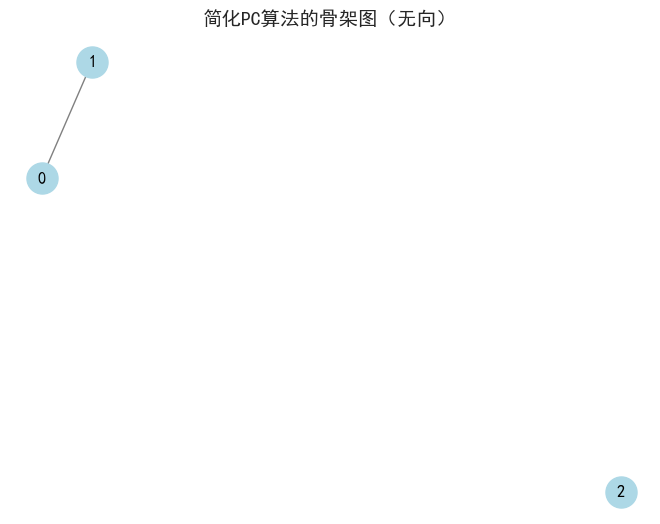

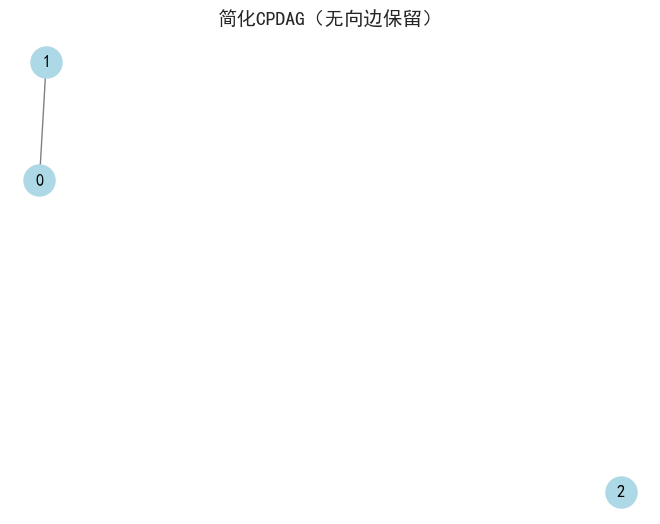

In [8]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 模拟数据：与第一段相同（100个样本，3个变量）
np.random.seed(42)
data = np.random.multivariate_normal(
    mean=[0, 0, 0],
    cov=[[1, 0.5, 0.2],
         [0.5, 1, 0.3],
         [0.2, 0.3, 1]],
    size=100
)

# 计算相关系数矩阵（用于骨架构建）
corr_matrix = np.corrcoef(data, rowvar=False)  # rowvar=False表示每列是一个变量
print("\n数据的相关系数矩阵：")
print(corr_matrix)

def make_skeleton(corr_matrix, threshold=0.7):
    """
    简化版骨架构建：基于相关系数阈值删除边（替代PC算法的条件独立检验）
    参数：
        corr_matrix: 相关系数矩阵
        threshold: 相关系数阈值（|r| > threshold 保留边，否则删除）
    返回：
        nx.Graph: 无向骨架图
    注意：
        真实PC算法的骨架构建需通过条件独立检验（而非简单阈值），此处仅为演示
    """
    G = nx.Graph()  # 初始化无向图
    num_vars = corr_matrix.shape[0]
    # 添加所有变量作为节点
    G.add_nodes_from(range(num_vars))

    # 遍历所有变量对，基于阈值判断是否保留边
    for i in range(num_vars):
        for j in range(i+1, num_vars):
            if abs(corr_matrix[i, j]) > threshold:
                G.add_edge(i, j)  # 相关系数超过阈值，添加边
    return G

def extend_skeleton(G):
    """
    简化版骨架扩展：直接将无向骨架视为CPDAG（无向边保留，不进行方向推断）
    参数：
        G: 无向骨架图
    返回：
        nx.Graph: 简化的CPDAG（实际仍是无向图）
    注意：
        真实PC算法的扩展需通过V结构识别和方向规则（如Rule1-4）推断边方向，此处仅为演示
    """
    DAG = G.copy()  # 简单复制骨架，不改变边的方向
    return DAG

def draw_graph(G, title):
    """
    绘制图形（用networkx和matplotlib）
    参数：
        G: nx.Graph或nx.DiGraph，待绘制的图
        title: str，图形标题
    """
    pos = nx.spring_layout(G)  # 使用spring布局（模拟物理力，使图美观）
    nx.draw(
        G,
        pos,
        with_labels=True,  # 显示节点标签
        node_color='lightblue',  # 节点颜色
        edge_color='gray',  # 边颜色
        font_size=12,
        node_size=500
    )
    plt.title(title, fontsize=14)
    plt.show()

# 运行简化版PC算法
skeleton = make_skeleton(corr_matrix, threshold=0.3)  # 降低阈值，使X-Y、Y-Z保留边
dag = extend_skeleton(skeleton)

# 绘制骨架和简化CPDAG
draw_graph(skeleton, "简化PC算法的骨架图（无向）")
draw_graph(dag, "简化CPDAG（无向边保留）")

PC 算法是因果发现的核心算法，分为两步：① 构建无向骨架（通过条件独立检验删除边）；② 扩展为 CPDAG（通过 V 结构和方向规则推断边方向）。

- 骨架构建用相关系数阈值替代条件独立检验（仅适用于强线性相关，无法处理条件依赖）；
- 骨架扩展仅复制无向边，不进行方向推断（真实 CPDAG 包含有向边和无向边，无向边表示因果方向不确定）。
-
- 适用场景：仅用于教学演示 PC 算法的基本流程，不适用于真实数据（需严格的条件独立检验和方向推断）。
- 可视化说明：networkx 的 spring 布局通过模拟节点间的排斥力和边的吸引力，使图的结构更清晰，适合小图（变量数 < 20）的可视化。

 PC 算法实现（骨架构建 + CPDAG 扩展）


PC算法的骨架矩阵：
     0    1    2    3    4    5    6
0  0.0  1.0  0.0  1.0  0.0  0.0  1.0
1  1.0  0.0  0.0  0.0  0.0  0.0  1.0
2  0.0  0.0  0.0  0.0  0.0  1.0  0.0
3  1.0  0.0  0.0  0.0  1.0  0.0  1.0
4  0.0  0.0  0.0  1.0  0.0  1.0  1.0
5  0.0  0.0  1.0  0.0  1.0  0.0  1.0
6  1.0  1.0  0.0  1.0  1.0  1.0  0.0

PC算法的CPDAG矩阵（1表示i→j）：
     0    1    2    3    4    5    6
0  0.0  1.0  0.0  1.0  0.0  0.0  1.0
1  1.0  0.0  0.0  0.0  0.0  0.0  1.0
2  0.0  0.0  0.0  0.0  0.0  1.0  0.0
3  1.0  0.0  0.0  0.0  1.0  0.0  1.0
4  0.0  0.0  0.0  1.0  0.0  1.0  1.0
5  0.0  0.0  0.0  0.0  0.0  0.0  0.0
6  0.0  0.0  0.0  0.0  0.0  0.0  0.0


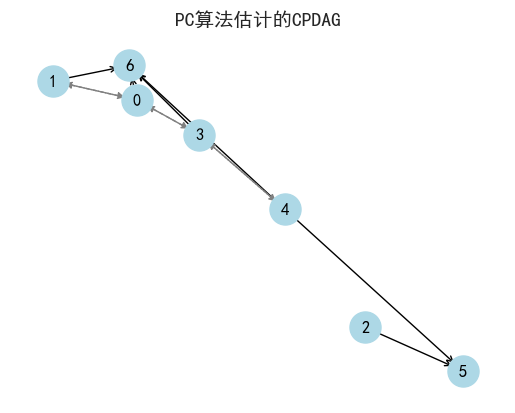

In [11]:
import numpy as np
import pandas as pd
from itertools import combinations  # 用于生成条件集的所有子集
import math
from scipy.stats import norm  # 用于正态分布的假设检验
import networkx as nx
from matplotlib import pyplot as plt
from scipy.linalg import pinv  # 用于计算广义逆矩阵

plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

def make_skeleton(V, corr_matrix, sample_num):
    """
    PC算法第一步：构建无向骨架（基于条件独立检验删除边）
    参数：
        V: list或array，变量名称列表（如['X','Y','Z']）
        corr_matrix: 相关系数矩阵（维度：len(V)×len(V)）
        sample_num: int，样本数量（用于Fisher变换的统计量计算）
    返回：
        C: 无向骨架矩阵（C[i][j]=1表示i和j有边，0表示无边）
        S: 分离集矩阵（S[i][j]表示使i和j独立的条件集）
    算法步骤：
        1. 初始化完全图（C为全1矩阵，对角线为0）
        2. 按条件集大小l从0开始递增，对每对相邻变量(i,j)，找l个条件变量的子集K
        3. 若i和j在K下条件独立，则删除i-j边，记录K为分离集S[i][j]
        4. 当所有条件集大小l下无新边删除时，停止并返回骨架
    """
    node_num = len(V)  # 变量个数
    # 1. 初始化骨架矩阵C（完全图，对角线为0）
    C = np.ones((node_num, node_num))
    for i in range(node_num):
        C[i, i] = 0  # 对角线元素为0（无自环）

    # 2. 初始化分离集矩阵S（每个元素为列表，存储分离集）
    S = [[[] for _ in range(node_num)] for __ in range(node_num)]

    # 3. 生成所有变量对（i,j），i<j（避免重复计算）
    pairs = []
    for i in range(node_num):
        for j in range(i+1, node_num):
            pairs.append((i, j))

    l = -1  # 条件集大小l，从0开始递增
    while True:
        l += 1
        flag = True  # 标记是否所有邻接集大小都小于l（用于判断是否终止循环）

        # 遍历所有变量对
        for (i, j) in pairs:
            # 若i和j仍相邻（C[i][j]=1）
            if C[i][j] == 1:
                # 获取i的邻接集（除j外）
                adj_set = get_adjSet(i, C, node_num)
                adj_set.remove(j)  # 排除j自身

                # 若邻接集大小 >= l（可生成l个元素的子集作为条件集）
                if len(adj_set) >= l:
                    flag = False  # 存在可处理的变量对，不终止循环

                    # 生成邻接集中l个元素的所有子集（条件集K）
                    for K in combinations(adj_set, l):
                        # 检验i和j在K下是否条件独立
                        if indep_judge(i, j, list(K), corr_matrix, sample_num):
                            # 若独立，删除i-j双向边
                            C[i][j] = 0
                            C[j][i] = 0
                            # 记录分离集
                            S[i][j] = list(K)
                            S[j][i] = list(K)
                            break  # 找到一个分离集即可，无需再检验其他子集

        # 若所有邻接集大小都小于l，无新边删除，终止循环
        if flag:
            break

    return C, S

def indep_judge(i, j, K, corr_matrix, sample_num):
    """
    条件独立检验：基于偏相关系数的Fisher变换和正态检验
    参数：
        i, j: int，待检验的两个变量的索引
        K: list，条件集变量的索引列表
        corr_matrix: 相关系数矩阵
        sample_num: int，样本数量
    返回：
        bool: True表示条件独立，False表示条件依赖
    原理：
        1. 计算i和j在K下的偏相关系数r_ij|K；
        2. Fisher变换：z = 0.5 * ln((1+r)/(1-r))，使z服从正态分布；
        3. 计算检验统计量z_standard = z * sqrt(n - |K| - 3)（n为样本数）；
        4. 双侧检验：若p值 >= alpha（0.005），则认为独立。
    """
    # 1. 计算条件偏相关系数r_ij|K
    if len(K) == 0:
        # 条件集为空，偏相关系数 = 边际相关系数
        r = corr_matrix[i, j]
    else:
        # 提取子相关系数矩阵：包含i、j和条件集K
        sub_corr = corr_matrix[np.ix_([i, j] + K, [i, j] + K)]
        # 计算子相关矩阵的广义逆（避免奇异矩阵）
        sub_corr_inv = pinv(sub_corr)
        # 偏相关系数公式：r_ij|K = -sub_corr_inv[0,1] / sqrt(sub_corr_inv[0,0] * sub_corr_inv[1,1])
        numerator = -sub_corr_inv[0, 1]
        denominator = math.sqrt(abs(sub_corr_inv[0, 0] * sub_corr_inv[1, 1]))
        r = numerator / denominator if denominator != 0 else 0

    # 2. 限制r在(-1,1)内（避免数值误差导致的超出范围）
    r = max(min(r, 0.99999), -0.99999)

    # 3. Fisher变换
    z = 0.5 * math.log((1 + r) / (1 - r))  # 等价于math.log1p(2r/(1-r))，更简洁

    # 4. 计算标准正态统计量（自由度：n - |K| - 3）
    df = sample_num - len(K) - 3
    z_standard = z * math.sqrt(df) if df > 0 else 0

    # 5. 双侧检验：计算p值（2*(1 - 累积分布函数值)）
    alpha = 0.005  # 显著性水平（严格的检验，降低假阳性）
    p_value = 2 * (1 - norm.cdf(abs(z_standard)))  # norm.cdf是标准正态累积分布函数

    # 6. 若p值 >= alpha，认为条件独立
    return p_value >= alpha

def extend_CPDAG(V, C, S):
    """
    PC算法第二步：将无向骨架扩展为CPDAG（完全部分有向无环图）
    参数：
        V: 变量名称列表
        C: 无向骨架矩阵
        S: 分离集矩阵
    返回：
        G: CPDAG矩阵（G[i][j]=1表示i→j，0表示无向或无边）
    算法步骤（基于PC算法的经典规则）：
        1. 识别V结构（i-j-k，i和k无边，j不在S[i][k]中 → i→j←k）；
        2. 应用方向规则1-4，推断其他边的方向（避免环和矛盾）。
    """
    node_num = len(V)
    # 初始化CPDAG矩阵（复制骨架，后续逐步将无向边转为有向边）
    G = C.copy()

    # 1. 生成所有可能的三元组（i,j,k），其中i-j和j-k是边，i-k不是边
    triples = []
    # 先生成所有相邻变量对
    pairs = [(i, j) for i in range(node_num) for j in range(node_num) if i != j and C[i][j] == 1]
    # 基于相邻对生成三元组
    for (i, j) in pairs:
        for k in range(node_num):
            if k != i and C[j][k] == 1 and C[i][k] == 0:
                triples.append([i, j, k])

    # 规则0：识别V结构（i-j-k → i→j←k）
    for [i, j, k] in triples:
        # 若j不在i和k的分离集中（S[i][k]），则为V结构
        if j not in S[i][k]:
            # 将i-j转为i→j，j-k转为j←k（即G[j][i]=0，G[j][k]=0）
            G[j][i] = 0
            G[j][k] = 0

    # 规则1：若i→j-k且i和k无边，则j→k
    for [i, j, k] in triples:
        if G[i][j] == 1 and G[j][i] == 0 and G[j][k] == 1 and G[k][j] == 1 and G[i][k] == 0:
            G[k][j] = 0  # j→k（删除k→j的边）

    # 规则2：若i→j→k且i-k是边，则i→k
    for [i, j, k] in triples:
        if G[i][j] == 1 and G[j][i] == 0 and G[j][k] == 1 and G[k][j] == 0 and G[i][k] == 1 and G[k][i] == 1:
            G[k][i] = 0  # i→k（删除k→i的边）

    # 规则3：若i-j→k和i-l→k且i-k是边，则i→k
    for [i, j, k] in triples:
        # 找另一个与i相邻且指向k的节点l
        for l in range(node_num):
            if l != j and l != k and C[i][l] == 1 and G[l][k] == 1 and G[k][l] == 0:
                if G[i][k] == 1 and G[k][i] == 1:
                    G[k][i] = 0  # i→k（删除k→i的边）

    # 规则4：若i-j→k→l且i-l是边，则i→l
    for [i, j, k] in triples:
        # 找k指向的节点l（k→l）
        for l in range(node_num):
            if l != i and G[k][l] == 1 and G[l][k] == 0 and C[i][l] == 1 and G[l][i] == 1:
                G[l][i] = 0  # i→l（删除l→i的边）

    return G

def get_adjSet(i, G, node_num):
    """
    辅助函数：获取节点i在图G中的邻接集（无向边）
    参数：
        i: 节点索引
        G: 邻接矩阵（无向）
        node_num: 节点总数
    返回：
        list: 邻接节点的索引列表
    """
    adj_set = []
    for j in range(node_num):
        if G[i][j] == 1:
            adj_set.append(j)
    return adj_set

def Draw(DAG, nodes):
    """
    绘制CPDAG（有向边和无向边）
    参数：
        DAG: CPDAG矩阵
        nodes: 变量名称列表
    """
    G = nx.DiGraph()  # 有向图（支持有向边）
    G.add_nodes_from(nodes)  # 添加节点

    # 添加有向边（i→j 当且仅当 DAG[i][j]=1 且 DAG[j][i]=0）
    node_num = len(nodes)
    for i in range(node_num):
        for j in range(node_num):
            if i != j:
                if DAG[i][j] == 1 and DAG[j][i] == 0:
                    G.add_edge(nodes[i], nodes[j])  # 有向边
                elif DAG[i][j] == 1 and DAG[j][i] == 1:
                    # 无向边（用networkx的无向边表示，实际CPDAG中无向边需保留）
                    G.add_edge(nodes[i], nodes[j], style='dashed')  # 虚线表示无向边

    # 绘制图形
    pos = nx.spring_layout(G)
    # 绘制有向边
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v) for u, v, d in G.edges(data=True) if d.get('style') != 'dashed'], arrowstyle='->', edge_color='black')
    # 绘制无向边（虚线）
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v) for u, v, d in G.edges(data=True) if d.get('style') == 'dashed'], style='dashed', edge_color='gray')
    # 绘制节点和标签
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
    nx.draw_networkx_labels(G, pos, font_size=12)

    plt.title("PC算法估计的CPDAG", fontsize=14)
    plt.axis('off')  # 关闭坐标轴
    plt.show()

def PC(data_path):
    """
    完整PC算法的主函数：读取数据→计算相关系数→构建骨架→扩展CPDAG→绘制结果
    参数：
        data_path: str，数据文件路径（CSV格式，每行样本，每列变量）
    返回：
        CPDAG: CPDAG矩阵
    """
    # 1. 读取数据
    df = pd.read_csv(data_path, index_col=False)  # 不读取行索引
    # 2. 计算相关系数矩阵
    corr_matrix = df.corr().values
    # 3. 样本数量
    sample_num = df.shape[0]
    # 4. 变量名称列表
    nodes = df.columns.values

    # 5. 构建无向骨架
    skeleton, separate_set = make_skeleton(nodes, corr_matrix, sample_num)
    print("\nPC算法的骨架矩阵：")
    print(pd.DataFrame(skeleton, index=nodes, columns=nodes))

    # 6. 扩展为CPDAG
    CPDAG = extend_CPDAG(nodes, skeleton, separate_set)
    print("\nPC算法的CPDAG矩阵（1表示i→j）：")
    print(pd.DataFrame(CPDAG, index=nodes, columns=nodes))

    # 7. 绘制CPDAG
    Draw(CPDAG, nodes)

    return CPDAG

if __name__ == '__main__':
    # 数据文件路径（替换为你的数据路径，CSV格式）
    data_path = r'F:/AAAAAAAAAAAAAAAAAAAAA/Senior/subject/数据挖掘/实验十(3)/SimulateData.csv'
    # 运行完整PC算法
    PC(data_path)

标准 PC 算法的完整实现，严格遵循 “骨架构建→CPDAG 扩展” 两步流程，是因果发现领域的经典算法。

关键改进（对比简化版）：
- 骨架构建用偏相关系数 + Fisher 变换做条件独立检验（适用于线性高斯数据，结果更可靠）；
- （l 从 0 开始，逐步增加，确保找到最小分离集）；
- CPDAG 扩展用了 PC 算法的经典规则（V 结构识别 + 4 个方向规则），能准确推断有向边和无向边（无向边表示因果方向不确定）。
- 适用场景：线性高斯数据的因果发现（如基因表达数据、经济指标数据等），需满足因果马尔可夫性和忠实性假设。

局限性：
- 计算复杂度高（变量数 d 时，条件集子集数为 O (2^d)），不适用于高维数据（d>20）；
- 仅适用于线性关系，非线性数据需替换条件独立检验方法（如核方法、互信息等）。

NOTEARS 算法（基于优化的 DAG 学习）

In [ ]:
# notears 是一个用于学习因果结构（特别是 DAG）的第三方库

In [14]:
pip install notears

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement notears (from versions: none)
ERROR: No matching distribution found for notears


In [12]:
import numpy as np
import scipy.linalg as slin
import scipy.optimize as sopt
from scipy.special import expit as sigmoid  # sigmoid函数（用于logistic损失）

def notears_linear(X, lambda1, loss_type, max_iter=100, h_tol=1e-8, rho_max=1e+16, w_threshold=0.3):
    """
    NOTEARS算法：基于优化的DAG学习（无环约束通过矩阵指数实现）
    参数：
        X: np.ndarray，样本矩阵（n×d，n为样本数，d为变量数）
        lambda1: float，L1正则化参数（控制边的稀疏性）
        loss_type: str，损失函数类型（'l2'：线性回归损失；'logistic'：逻辑回归损失；'poisson'：泊松回归损失）
        max_iter: int，最大迭代次数（增广拉格朗日方法的迭代次数）
        h_tol: float，无环约束的容忍度（|h(W)| ≤ h_tol 视为满足无环）
        rho_max: float，增广拉格朗日方法的惩罚参数上限（避免rho过大导致数值不稳定）
        w_threshold: float，权重阈值（|W[i][j]| < w_threshold 视为无边）
    返回：
        W_est: np.ndarray，估计的DAG权重矩阵（W[i][j]≠0表示i→j有边，值为权重）
    核心思想：
        将DAG学习转化为带约束的优化问题：min_W L(W;X) + lambda1||W||_1，s.t. h(W)=0（h(W)是无环约束）
        - L(W;X)：损失函数（衡量W对数据的拟合程度）
        - lambda1||W||_1：L1正则化（鼓励稀疏，减少假阳性边）
        - h(W) = tr(exp(W⊙W)) - d：无环约束（W⊙W是元素-wise乘积，exp是矩阵指数，tr是迹；DAG的矩阵指数迹为d）
    """
    def _loss(W):
        """
        计算损失函数值和梯度（内部辅助函数）
        参数：
            W: 权重矩阵（d×d）
        返回：
            loss: 损失函数值
            G_loss: 损失函数对W的梯度（d×d）
        """
        M = X @ W  # 预测值矩阵（n×d）
        if loss_type == 'l2':
            # 线性回归损失（适用于连续数据）
            R = X - M  # 残差矩阵（n×d）
            loss = 0.5 / X.shape[0] * (R ** 2).sum()  # 平均损失
            G_loss = -1.0 / X.shape[0] * X.T @ R  # 梯度（d×d）
        elif loss_type == 'logistic':
            # 逻辑回归损失（适用于二分类数据）
            loss = 1.0 / X.shape[0] * (np.logaddexp(0, M) - X * M).sum()
            G_loss = 1.0 / X.shape[0] * X.T @ (sigmoid(M) - X)
        elif loss_type == 'poisson':
            # 泊松回归损失（适用于计数数据）
            S = np.exp(M)  # 泊松分布的均值
            loss = 1.0 / X.shape[0] * (S - X * M).sum()
            G_loss = 1.0 / X.shape[0] * X.T @ (S - X)
        else:
            raise ValueError(f"未知的损失函数类型：{loss_type}，支持'l2'、'logistic'、'poisson'")
        return loss, G_loss

    def _h(W):
        """
        计算无环约束函数值和梯度（内部辅助函数）
        参数：
            W: 权重矩阵（d×d）
        返回：
            h: 约束函数值（h=0表示无环）
            G_h: 约束函数对W的梯度（d×d）
        原理：
            DAG的邻接矩阵W满足tr(exp(W⊙W))=d（矩阵指数的迹等于节点数）；
            若存在环，tr(exp(W⊙W))>d，故h=tr(exp(W⊙W))-d>0。
        """
        W_sq = W * W  # 元素-wise平方（避免负权重影响）
        E = slin.expm(W_sq)  # 矩阵指数（expm是scipy的矩阵指数函数，数值稳定）
        h = np.trace(E) - d  # 约束函数值（tr(E)是矩阵E的迹）
        G_h = E.T * W * 2  # 约束函数的梯度（通过自动微分推导，简化形式）
        return h, G_h

    def _adj(w):
        """
        将“双变量”向量w转换为权重矩阵W（内部辅助函数）
        参数：
            w: 双变量向量（2d²×1，前d²个元素是W的正部分，后d²个是负部分）
        返回：
            W: 权重矩阵（d×d），W = w_pos - w_neg（w_pos≥0，w_neg≥0）
        目的：
            将W的优化转化为对非负变量w_pos和w_neg的优化，便于施加非负约束。
        """
        d = int(np.sqrt(len(w) / 2))  # 从w的长度反推变量数d
        w_pos = w[:d*d].reshape(d, d)  # 正部分
        w_neg = w[d*d:].reshape(d, d)  # 负部分
        return w_pos - w_neg

    def _func(w):
        """
        计算增广拉格朗日函数值和梯度（内部辅助函数）
        参数：
            w: 双变量向量（2d²×1）
        返回：
            obj: 增广拉格朗日函数值
            g_obj: 增广拉格朗日函数对w的梯度（2d²×1）
        增广拉格朗日函数：
            L(W, α, ρ) = L(W) + α*h(W) + 0.5*ρ*h(W)² + lambda1*||W||_1
            其中α是拉格朗日乘子，ρ是惩罚参数。
        """
        W = _adj(w)  # 转换为权重矩阵
        loss, G_loss = _loss(W)  # 损失函数和梯度
        h, G_h = _h(W)  # 约束函数和梯度

        # 增广拉格朗日函数值
        obj = loss + alpha * h + 0.5 * rho * h ** 2 + lambda1 * np.sum(w)  # ||W||_1 = sum(w_pos + w_neg) = sum(w)

        # 增广拉格朗日函数的梯度（对w的梯度）
        # 对w_pos的梯度：G_loss + (alpha + rho*h)*G_h + lambda1
        # 对w_neg的梯度：-G_loss - (alpha + rho*h)*G_h + lambda1
        G_smooth = G_loss + (rho * h + alpha) * G_h  # 平滑部分的梯度（对W）
        g_obj = np.concatenate([G_smooth + lambda1, -G_smooth + lambda1], axis=None)  # 转换为对w的梯度
        return obj, g_obj

    # 初始化参数
    n, d = X.shape  # 样本数n，变量数d
    w_est = np.zeros(2 * d * d)  # 双变量向量初始化（全0）
    rho = 1.0  # 惩罚参数初始化
    alpha = 0.0  # 拉格朗日乘子初始化
    h = np.inf  # 约束函数值初始化（无穷大）

    # 施加边界条件：w_pos和w_neg非负，且对角线元素为0（无自环）
    bnds = []
    for _ in range(2):  # 循环2次（w_pos和w_neg）
        for i in range(d):
            for j in range(d):
                if i == j:
                    bnds.append((0, 0))  # 对角线元素固定为0（无自环）
                else:
                    bnds.append((0, None))  # 非对角线元素非负

    # 数据预处理：l2损失时标准化（均值为0）
    if loss_type == 'l2':
        X = X - np.mean(X, axis=0, keepdims=True)  # 按列标准化（避免均值影响）

    # 增广拉格朗日方法迭代
    for _ in range(max_iter):
        w_new, h_new = None, None
        # 调整惩罚参数rho，直到约束满足或rho达到上限
        while rho < rho_max:
            # 用L-BFGS-B算法最小化增广拉格朗日函数（支持边界条件和梯度）
            sol = sopt.minimize(
                fun=_func,
                x0=w_est,
                method='L-BFGS-B',
                jac=True,  # 启用梯度（_func返回梯度）
                bounds=bnds,
                options={'maxiter': 1000, 'gtol': 1e-8}
            )
            w_new = sol.x  # 新的双变量向量
            h_new, _ = _h(_adj(w_new))  # 新的约束函数值

            # 若约束未改善（h_new > 0.25*h），增大rho；否则跳出循环
            if h_new > 0.25 * h:
                rho *= 10
            else:
                break

        # 更新参数
        w_est = w_new
        h = h_new
        alpha += rho * h  # 更新拉格朗日乘子

        # 收敛条件：约束满足（h ≤ h_tol）或rho达到上限
        if h <= h_tol or rho >= rho_max:
            break

    # 转换为权重矩阵，并应用阈值（删除弱边）
    W_est = _adj(w_est)
    W_est[np.abs(W_est) < w_threshold] = 0  # 弱边置0（控制稀疏性）

    return W_est

if __name__ == '__main__':
    # 导入notears工具包（需提前安装：pip install notears）
    from notears import utils

    # 1. 设置随机种子，保证结果可复现
    utils.set_random_seed(1)

    # 2. 模拟DAG和数据
    n = 100  # 样本数
    d = 20  # 变量数
    s0 = 20  # 真实DAG的边数
    graph_type = 'ER'  # DAG结构类型（ER： Erdős-Rényi随机图）
    sem_type = 'gauss'  # SEM类型（gauss：高斯线性SEM）

    # 模拟真实DAG的邻接矩阵B_true（0-1矩阵，1表示有边）
    B_true = utils.simulate_dag(d, s0, graph_type)
    # 模拟真实DAG的权重矩阵W_true（B_true中1的位置赋予随机权重）
    W_true = utils.simulate_parameter(B_true)
    np.savetxt('W_true.csv', W_true, delimiter=',')  # 保存真实权重矩阵

    # 基于W_true模拟数据X（高斯线性SEM）
    X = utils.simulate_linear_sem(W_true, n, sem_type)
    np.savetxt('X.csv', X, delimiter=',')  # 保存模拟数据

    # 3. 运行NOTEARS算法（l2损失，适用于连续数据）
    W_est = notears_linear(X, lambda1=0.1, loss_type='l2')

    # 4. 验证估计结果是DAG（notears工具包的辅助函数）
    assert utils.is_dag(W_est), "NOTEARS估计结果不是DAG！"

    # 5. 保存估计结果并计算准确率
    np.savetxt('W_est.csv', W_est, delimiter=',')  # 保存估计权重矩阵
    # 计算准确率（TPR：真阳性率，FPR：假阳性率，F1：F1分数）
    acc = utils.count_accuracy(B_true, W_est != 0)
    print("\nNOTEARS算法估计准确率：")
    print(f"真阳性率（TPR）：{acc['tpr']:.4f}")
    print(f"假阳性率（FPR）：{acc['fpr']:.4f}")
    print(f"F1分数：{acc['f1']:.4f}")

ModuleNotFoundError: No module named 'notears'

NOTEARS 是 2018 年提出的基于优化的 DAG 学习算法，突破了传统 PC 类算法的 “条件独立检验 + 方向推断” 框架，直接通过优化问题学习 DAG 的权重矩阵，适用于高维数据。

关键创新：
- 无环约束的巧妙表示：用矩阵指数的迹（tr (exp (W⊙W))=d）表示无环，避免了枚举所有环的 NP 难问题；
- 稀疏性控制：通过 L1 正则化鼓励权重矩阵稀疏，减少假阳性边；
- 高效优化：用增广拉格朗日方法将带约束优化转化为无约束优化，结合 L-BFGS-B 算法求解，效率高。

适用场景：
- 连续数据（loss_type='l2'）、二分类数据（loss_type='logistic'）、计数数据（loss_type='poisson'）；
- 高维数据（变量数 d>50），因为计算复杂度为 O (d³)，远低于 PC 算法的 O (2^d)。

优点：
- 无需条件独立检验，避免了检验的多重性问题；
- 直接学习权重矩阵，可量化因果效应强度；
- 支持高维数据，效率高。

局限性：
- 仅适用于线性关系（若为非线性，需扩展为 NOTEARS-NL 等变体）；
- 对超参数 lambda1 和 w_threshold 敏感，需调优（可通过交叉验证选择）。


In [15]:
import numpy as np
import scipy.linalg as slin
import scipy.optimize as sopt
from scipy.special import expit as sigmoid

def notears_linear(X, lambda1, loss_type, max_iter=100, h_tol=1e-8, rho_max=1e+16, w_threshold=0.3):
    """
    NOTEARS算法：基于优化的DAG学习（无环约束通过矩阵指数实现）
    参数：
        X: np.ndarray，样本矩阵（n×d，n为样本数，d为变量数）
        lambda1: float，L1正则化参数（控制边的稀疏性）
        loss_type: str，损失函数类型（'l2'：线性回归损失；'logistic'：逻辑回归损失；'poisson'：泊松回归损失）
        max_iter: int，最大迭代次数（增广拉格朗日方法的迭代次数）
        h_tol: float，无环约束的容忍度（|h(W)| ≤ h_tol 视为满足无环）
        rho_max: float，增广拉格朗日方法的惩罚参数上限（避免rho过大导致数值不稳定）
        w_threshold: float，权重阈值（|W[i][j]| < w_threshold 视为无边）
    返回：
        W_est: np.ndarray，估计的DAG权重矩阵（W[i][j]≠0表示i→j有边，值为权重）
    """
    def _loss(W):
        """计算损失函数值和梯度（内部辅助函数）"""
        M = X @ W
        if loss_type == 'l2':
            R = X - M
            loss = 0.5 / X.shape[0] * (R ** 2).sum()
            G_loss = -1.0 / X.shape[0] * X.T @ R
        elif loss_type == 'logistic':
            loss = 1.0 / X.shape[0] * (np.logaddexp(0, M) - X * M).sum()
            G_loss = 1.0 / X.shape[0] * X.T @ (sigmoid(M) - X)
        elif loss_type == 'poisson':
            S = np.exp(M)
            loss = 1.0 / X.shape[0] * (S - X * M).sum()
            G_loss = 1.0 / X.shape[0] * X.T @ (S - X)
        else:
            raise ValueError(f"未知的损失函数类型：{loss_type}，支持'l2'、'logistic'、'poisson'")
        return loss, G_loss

    def _h(W):
        """计算无环约束函数值和梯度（内部辅助函数）"""
        W_sq = W * W
        E = slin.expm(W_sq)
        h = np.trace(E) - d
        G_h = E.T * W * 2
        return h, G_h

    def _adj(w):
        """将“双变量”向量w转换为权重矩阵W（内部辅助函数）"""
        w_pos = w[:d*d].reshape(d, d)
        w_neg = w[d*d:].reshape(d, d)
        return w_pos - w_neg

    def _func(w):
        """计算增广拉格朗日函数值和梯度（内部辅助函数）"""
        W = _adj(w)
        loss, G_loss = _loss(W)
        h, G_h = _h(W)
        obj = loss + alpha * h + 0.5 * rho * h ** 2 + lambda1 * np.sum(w)
        G_smooth = G_loss + (rho * h + alpha) * G_h
        g_obj = np.concatenate([G_smooth + lambda1, -G_smooth + lambda1], axis=None)
        return obj, g_obj

    n, d = X.shape
    w_est = np.zeros(2 * d * d)
    rho = 1.0
    alpha = 0.0
    h = np.inf

    bnds = [(0, 0) if i == j else (0, None) for _ in range(2) for i in range(d) for j in range(d)]

    if loss_type == 'l2':
        X = X - np.mean(X, axis=0, keepdims=True)

    for _ in range(max_iter):
        w_new, h_new = None, None
        while rho < rho_max:
            sol = sopt.minimize(_func, w_est, method='L-BFGS-B', jac=True, bounds=bnds)
            w_new = sol.x
            h_new, _ = _h(_adj(w_new))
            if h_new > 0.25 * h:
                rho *= 10
            else:
                break

        w_est = w_new
        h = h_new
        alpha += rho * h

        if h <= h_tol or rho >= rho_max:
            break

    W_est = _adj(w_est)
    W_est[np.abs(W_est) < w_threshold] = 0
    return W_est

# ==============================================================================
# --- 以下是修改后的主程序部分 ---
# 用手动模拟替代了 notears.utils 的功能
# ==============================================================================
if __name__ == '__main__':
    # 1. 手动设置随机种子
    np.random.seed(1)

    # 2. 定义模拟参数
    n = 100  # 样本数
    d = 20  # 变量数
    s0 = 20  # 真实DAG的预期边数
    sem_type = 'gauss'  # SEM类型 (仅用于手动模拟)

    # 3. 手动模拟一个真实的DAG权重矩阵 W_true
    # 这部分功能类似于 notears.utils.simulate_dag 和 notears.utils.simulate_parameter
    print("正在手动模拟真实DAG权重矩阵 W_true...")
    B_true = np.zeros((d, d))
    for i in range(d):
        for j in range(i+1, d): # 确保是上三角矩阵，从而保证是DAG
            if np.random.rand() < s0 / d: # 以一定概率添加边
                B_true[i, j] = np.random.randn() * 0.5 # 赋予随机权重

    # 为了使模拟更真实，我们让权重矩阵更稀疏，并确保它是一个DAG
    # 一个简单的方法是只保留上三角部分的一些边
    mask = np.triu(np.ones((d, d)), k=1) # 上三角掩码
    W_true = B_true * mask

    np.savetxt('W_true.csv', W_true, delimiter=',')
    print("真实权重矩阵 W_true 已保存到 'W_true.csv'")

    # 4. 基于 W_true 手动模拟观测数据 X
    # 这部分功能类似于 notears.utils.simulate_linear_sem
    print("正在基于 W_true 模拟观测数据 X...")
    if sem_type == 'gauss':
        # 线性高斯模型: X = X @ W_true + 噪声
        X = np.random.randn(n, d)
        for _ in range(100): # 使用迭代方法确保数据稳定
            X = X @ W_true + np.random.randn(n, d) * 0.5

    np.savetxt('X.csv', X, delimiter=',')
    print("模拟数据 X 已保存到 'X.csv'")

    # 5. 运行 NOTEARS 算法
    print("开始运行 NOTEARS 算法...")
    W_est = notears_linear(X, lambda1=0.1, loss_type='l2')
    print("NOTEARS 算法运行完毕。")

    # 6. 验证估计结果是否为DAG (一个简单的检查)
    # 这部分功能类似于 notears.utils.is_dag
    def is_dag(W):
        return np.trace(slin.expm(W * W)) - d < 1e-8

    if is_dag(W_est):
        print("估计结果 W_est 是一个DAG。")
    else:
        print("警告：估计结果 W_est 可能不是一个DAG。")

    # 7. 保存并简单评估结果
    np.savetxt('W_est.csv', W_est, delimiter=',')
    print("估计权重矩阵 W_est 已保存到 'W_est.csv'")

    # 简单的评估：计算估计边与真实边的吻合程度
    # 这部分功能类似于 notears.utils.count_accuracy
    print("\n--- 简单评估结果 ---")
    # 将权重矩阵转换为0-1邻接矩阵
    B_est = (np.abs(W_est) > 0).astype(int)

    # 计算 真阳性(TP), 假阳性(FP), 真阴性(TN), 假阴性(FN)
    TP = np.sum(B_est * B_true)
    FP = np.sum(B_est * (1 - B_true))
    TN = np.sum((1 - B_est) * (1 - B_true))
    FN = np.sum((1 - B_est) * B_true)

    # 计算准确率指标
    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # 真阳性率
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0.0  # 假阳性率
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    f1 = 2 * tpr * precision / (tpr + precision) if (tpr + precision) > 0 else 0.0

    print(f"真阳性率 (TPR): {tpr:.4f}")
    print(f"假阳性率 (FPR): {fpr:.4f}")
    print(f"F1 分数: {f1:.4f}")

正在手动模拟真实DAG权重矩阵 W_true...
真实权重矩阵 W_true 已保存到 'W_true.csv'
正在基于 W_true 模拟观测数据 X...
模拟数据 X 已保存到 'X.csv'
开始运行 NOTEARS 算法...
NOTEARS 算法运行完毕。
估计结果 W_est 是一个DAG。
估计权重矩阵 W_est 已保存到 'W_est.csv'

--- 简单评估结果 ---
真阳性率 (TPR): 0.2183
假阳性率 (FPR): 0.0804
F1 分数: 0.1237
